In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Загружаем данные

In [14]:
# Загружаем только необходимые колонки
df = pd.read_excel('data_orphans_127_v20241218.xlsx', 
        usecols=['year', 'region', 'indicator_category', 'dimension', 
        'main_level', 'indicator', 'indicator_value'])

# Быстро проверим размер
print(df.shape)
print(df.head(2))

(864205, 7)
   year             region                                 indicator_category  \
0  2014  Республика Адыгея  1. Учет и устройство детей, оставшихся без поп...   
1  2014  Республика Адыгея  1. Учет и устройство детей, оставшихся без поп...   

  dimension                                         main_level  \
0     всего  детей выявлено и учтено, всего, на конец отчет...   
1     всего  детей выявлено и учтено, всего, на конец отчет...   

                                           indicator  indicator_value  
0  детей, оставшихся неустроенными к началу отчет...                1  
1       детей, выявленных и учтенных за отчетный год              172  


___

# Семьи, готовые усыновить детей VS дети на предварительной опеке — точечная диаграмма (scatter) по регионам за выбранный 2020 год

In [3]:
df_4 = df[df['indicator_category'] == '4. Граждан, желающих принять ребенка на воспитание в семьи']
print("Уникальные main_level:")
print(df_4['main_level'].unique())
print("\nУникальные indicator:")
print(df_4['indicator'].unique())

Уникальные main_level:
<StringArray>
[                                                                       'состояло на учете семей, желающих принять ребенка на воспитание в семью, на начало года, всего',
                                      'состояло на учете семей, желающих принять ребенка на воспитание в семью, в органах опеки и попечительства, на начало года, всего',
                                   'состояло на учете семей, желающих принять ребенка на воспитание в семью, в региональном банке данных о детях, на начало года, всего',
                                                                      'поставлено на учет семей, желающих принять ребенка на воспитание в семью, за отчетный год, всего',
                                    'поставлено на учет семей, желающих принять ребенка на воспитание в семью, за отчетный год, в органах опеки и попечительства, всего',
                                 'поставлено на учет семей, желающих принять ребенка на воспитание в семью, за от

In [4]:
mask_pre = df['main_level'].str.contains('предварительную опеку', na=False)
df_pre = df[mask_pre]
print(df_pre[['indicator_category', 'dimension', 'main_level', 'indicator']].drop_duplicates())

                                   indicator_category dimension  \
12  1. Учет и устройство детей, оставшихся без поп...     всего   
13  1. Учет и устройство детей, оставшихся без поп...     всего   
14  1. Учет и устройство детей, оставшихся без поп...     всего   
15  1. Учет и устройство детей, оставшихся без поп...     всего   
18  1. Учет и устройство детей, оставшихся без поп...     всего   

                                           main_level  \
12  устроено под предварительную опеку (попечитель...   
13  устроено под предварительную опеку (попечитель...   
14  устроено под предварительную опеку (попечитель...   
15  устроено под предварительную опеку (попечитель...   
18  устроено под предварительную опеку (попечитель...   

                                            indicator  
12  находятся под предварительной опекой на конец ...  
13  по истечении установленного срока были помещен...  
14  по истечении установленного срока переданы на ...  
15  по истечении установленног

In [23]:
# Ищем все строки с нужным main_level (без фильтра по dimension и категории)
target_main = 'состоит на учете семей, желающих принять ребенка на воспитание в семью, на конец года, всего'
mask = df['main_level'] == target_main
df_test = df[mask]

print("Найдено строк:", len(df_test))
if len(df_test) > 0:
    print("Уникальные indicator_category:", df_test['indicator_category'].unique())
    print("Уникальные dimension:", df_test['dimension'].unique())
    print("Первые 3 строки (год, регион, dimension, indicator_value):")
    print(df_test[['year', 'region', 'dimension', 'indicator_value']].head(3))
else:
    print("Точное совпадение не найдено. Проверьте написание.")
    # Поиск по части строки
    mask_part = df['main_level'].str.contains('состоит на учете семей.*на конец года', na=False, case=False)
    df_part = df[mask_part]
    print("Строк по частичному совпадению:", len(df_part))
    if len(df_part) > 0:
        print("Примеры main_level из частичного совпадения:")
        print(df_part['main_level'].unique())

Найдено строк: 8610
Уникальные indicator_category: <StringArray>
['4. Граждан, желающих принять ребенка на воспитание в семьи']
Length: 1, dtype: str
Уникальные dimension: <StringArray>
[               'Опекуны (попечители), всего',
    'Опекуны (попечители), приемные родители',
 'Опекуны (попечители), патронатные родители',
                         'Усыновители, всего',
          'Усыновители, иностранные граждане']
Length: 5, dtype: str
Первые 3 строки (год, регион, dimension, indicator_value):
        year             region                    dimension  indicator_value
577477  2014  Республика Адыгея  Опекуны (попечители), всего               65
577482  2014  Республика Адыгея  Опекуны (попечители), всего                3
577516  2014   Республика Алтай  Опекуны (попечители), всего               63


In [20]:
df_4 = df[df['indicator_category'] == '4. Граждан, желающих принять ребенка на воспитание в семьи']
print("Уникальные main_level в категории 4:")
for val in df_4['main_level'].unique():
    print(f"  '{val}'")

Уникальные main_level в категории 4:
  'состояло на учете семей, желающих принять ребенка на воспитание в семью, на начало года, всего'
  'состояло на учете семей, желающих принять ребенка на воспитание в семью, в органах опеки и попечительства, на начало года, всего'
  'состояло на учете семей, желающих принять ребенка на воспитание в семью, в региональном банке данных о детях, на начало года, всего'
  'поставлено на учет семей, желающих принять ребенка на воспитание в семью, за отчетный год, всего'
  'поставлено на учет семей, желающих принять ребенка на воспитание в семью, за отчетный год, в органах опеки и попечительства, всего'
  'поставлено на учет семей, желающих принять ребенка на воспитание в семью, за отчетный год, в региональном банке данных о детях, всего'
  'снято с учета семей, желающих принять ребенка на воспитание в семью, за отчетный год, всего'
  'снято с учета семей, желающих принять ребенка на воспитание в семью, за отчетный год, в органах опеки и попечительства, вс

In [28]:
mask_usyn = (df['main_level'] == 'состоит на учете семей, желающих принять ребенка на воспитание в семью, на конец года, всего') & \
            (df['dimension'] == 'Усыновители, всего')
df_usyn = df[mask_usyn]
print("Количество строк для усыновителей:", len(df_usyn))
print(df_usyn[['year', 'region', 'indicator_value']].head())

Количество строк для усыновителей: 1722
        year                   region  indicator_value
708400  2014        Республика Адыгея               40
708405  2014        Республика Адыгея                3
708439  2014         Республика Алтай               25
708444  2014         Республика Алтай               13
708478  2014  Республика Башкортостан              685


___

In [4]:
df_fams = df[
    (df['indicator_category'] == '4. Граждан, желающих принять ребенка на воспитание в семьи') &
    (df['dimension'] == 'Усыновители, всего') &
    (df['main_level'] == 'состоит на учете семей, желающих принять ребенка на воспитание в семью, на конец года, всего')
]

df_preopeka = df[(df['indicator_category'] == '1. Учет и устройство детей, оставшихся без попечения родителей') & \
                (df['dimension'] == 'всего') & \
                (df['main_level'] == 'устроено под предварительную опеку (попечительство), из всех детей выявленных и учтенных, на конец отчетного года') & \
                (df['indicator'] == 'находятся под предварительной опекой на конец отчетного года')
]

Регионов с данными за 2020: 172


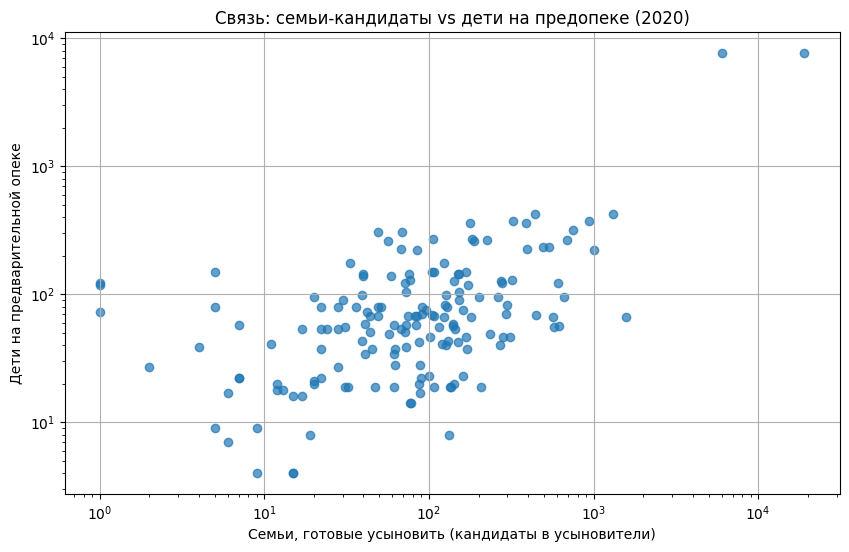

In [7]:
year = 2020

families_year = df_fams[df_fams['year'] == year][['region', 'indicator_value']].copy()
families_year.rename(columns={'indicator_value': 'families'}, inplace=True)

# Данные по предварительной опеке у вас уже есть (df_preopeka)
preopeka_year = df_preopeka[df_preopeka['year'] == year][['region', 'indicator_value']].copy()
preopeka_year.rename(columns={'indicator_value': 'preopeka_children'}, inplace=True)

# Объединение
scatter_data = pd.merge(families_year, preopeka_year, on='region', how='inner')
print(f"Регионов с данными за {year}: {len(scatter_data)}")

if len(scatter_data) > 0:
    plt.figure(figsize=(10,6))
    plt.xscale('log')
    plt.yscale('log')
    plt.scatter(scatter_data['families'], scatter_data['preopeka_children'], alpha=0.7)
    plt.xlabel('Семьи, готовые усыновить (кандидаты в усыновители)')
    plt.ylabel('Дети на предварительной опеке')
    plt.title(f'Связь: семьи-кандидаты vs дети на предопеке ({year})')
    # for _, row in scatter_data.iterrows():
    #     plt.annotate(row['region'], (row['families'], row['preopeka_children']), fontsize=8)
    plt.grid(True)
    plt.show()
else:
    print("Нет данных для построения. Проверьте год или фильтры.")
    

In [8]:
# Проверим, есть ли дубликаты регионов в families_year и preopeka_year
print("Дубликаты в families_year:", families_year['region'].duplicated().sum())
print("Дубликаты в preopeka_year:", preopeka_year['region'].duplicated().sum())

Дубликаты в families_year: 86
Дубликаты в preopeka_year: 0


In [10]:
families_year = families_year.groupby('region', as_index=False)['families'].sum()
preopeka_year = preopeka_year.groupby('region', as_index=False)['preopeka_children'].sum()

Регионов с ненулевыми данными за 2020: 84


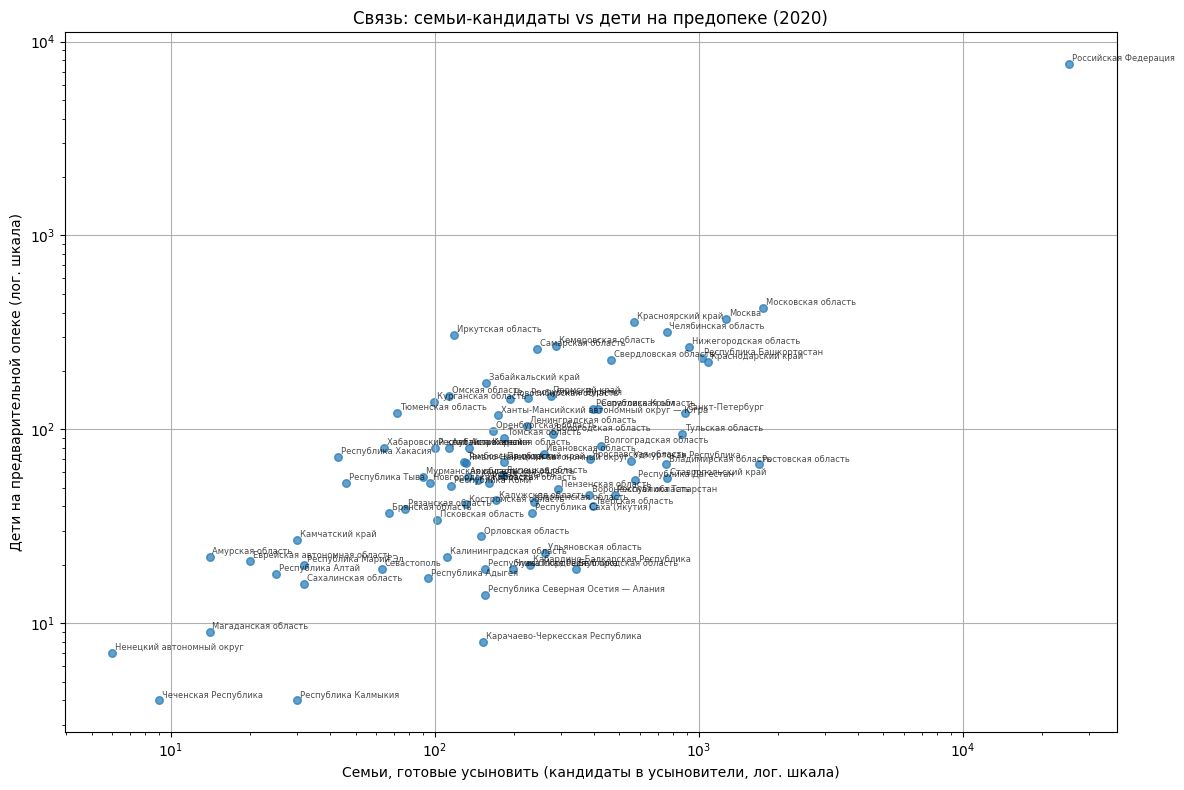

In [11]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

year = 2020

# Фильтруем данные за год
# families_year = df_fams[df_fams['year'] == year][['region', 'indicator_value']].copy()
families_year.rename(columns={'indicator_value': 'families'}, inplace=True)

# preopeka_year = df_preopeka[df_preopeka['year'] == year][['region', 'indicator_value']].copy()
preopeka_year.rename(columns={'indicator_value': 'preopeka_children'}, inplace=True)

# Объединение
scatter_data = pd.merge(families_year, preopeka_year, on='region', how='inner')

# Заменяем нули на NaN, затем удаляем строки с NaN (логарифм не вычислит)
scatter_data = scatter_data.replace(0, np.nan).dropna()
print(f"Регионов с ненулевыми данными за {year}: {len(scatter_data)}")

if len(scatter_data) > 0:
    plt.figure(figsize=(12, 8))
    
    # Логарифмическая шкала (теперь все значения > 0)
    plt.xscale('log')
    plt.yscale('log')
    
    # Строим scatter
    plt.scatter(scatter_data['families'], scatter_data['preopeka_children'], alpha=0.7, s=30)
    
    # Подписываем точки (только после создания фигуры!)
    for _, row in scatter_data.iterrows():
        plt.annotate(row['region'], 
                     (row['families'], row['preopeka_children']), 
                     fontsize=6, 
                     alpha=0.7,
                     xytext=(2, 2),
                     textcoords='offset points')
    
    plt.xlabel('Семьи, готовые усыновить (кандидаты в усыновители, лог. шкала)')
    plt.ylabel('Дети на предварительной опеке (лог. шкала)')
    plt.title(f'Связь: семьи-кандидаты vs дети на предопеке ({year})')
    plt.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print("Нет данных для построения (все нули или пропуски).")

In [26]:
print("Семей:", len(df_fams))
print("Детей на предопеке:", len(df_preopeka))
print("Семей за год", year, ":", len(families_year))
print("Предопека за год", year, ":", len(preopeka_year))

Семей: 1722
Детей на предопеке: 861
Семей за год 2022 : 0
Предопека за год 2022 : 86


# Количество усыновлённых детей по годам и регионам — таблица/сводная таблица (строки — регионы, столбцы — годы, значения — количество).

In [18]:
# Поиск всех строк с "усыновл" в indicator
mask_adopt = df['indicator'].str.contains('усыновл', case=False, na=False)
print(df[mask_adopt][['indicator', 'indicator_category', 'dimension', 'main_level']].drop_duplicates().to_string())

                                                                                                                                                                                                indicator                                              indicator_category                                  dimension                                                                                                         main_level
18                                                                                                                    по истечении установленного срока усыновлены предварительным опекуном (попечителем)  1. Учет и устройство детей, оставшихся без попечения родителей                                      всего  устроено под предварительную опеку (попечительство), из всех детей выявленных и учтенных, на конец отчетного года
24                                                                                                                                                      

In [19]:
adopt_df = df[
    (df['indicator_category'] == '3. Устройство детей в семьи') &
    (df['dimension'] == 'устроено в семьи, всего') &
    (df['indicator'] == 'численность усыновленных детей на конец года')
]
print(adopt_df.shape)
print(adopt_df[['year', 'region', 'indicator_value']].head())

(861, 7)
        year                   region  indicator_value
422984  2014        Республика Адыгея               26
423016  2014         Республика Алтай               28
423048  2014  Республика Башкортостан              292
423080  2014       Республика Бурятия              102
423112  2014      Республика Дагестан              124


In [20]:
pivot_adopt = adopt_df.pivot_table(index='region', columns='year', values='indicator_value', aggfunc='sum', fill_value=0)
pivot_adopt.sum(axis=1).sort_values(ascending=False).head(10)

region
Российская Федерация       50379
Московская область          3001
Пермский край               2213
Санкт-Петербург             1844
Республика Башкортостан     1666
Ростовская область          1539
Кемеровская область         1249
Алтайский край              1207
Москва                      1192
Самарская область           1075
dtype: int64

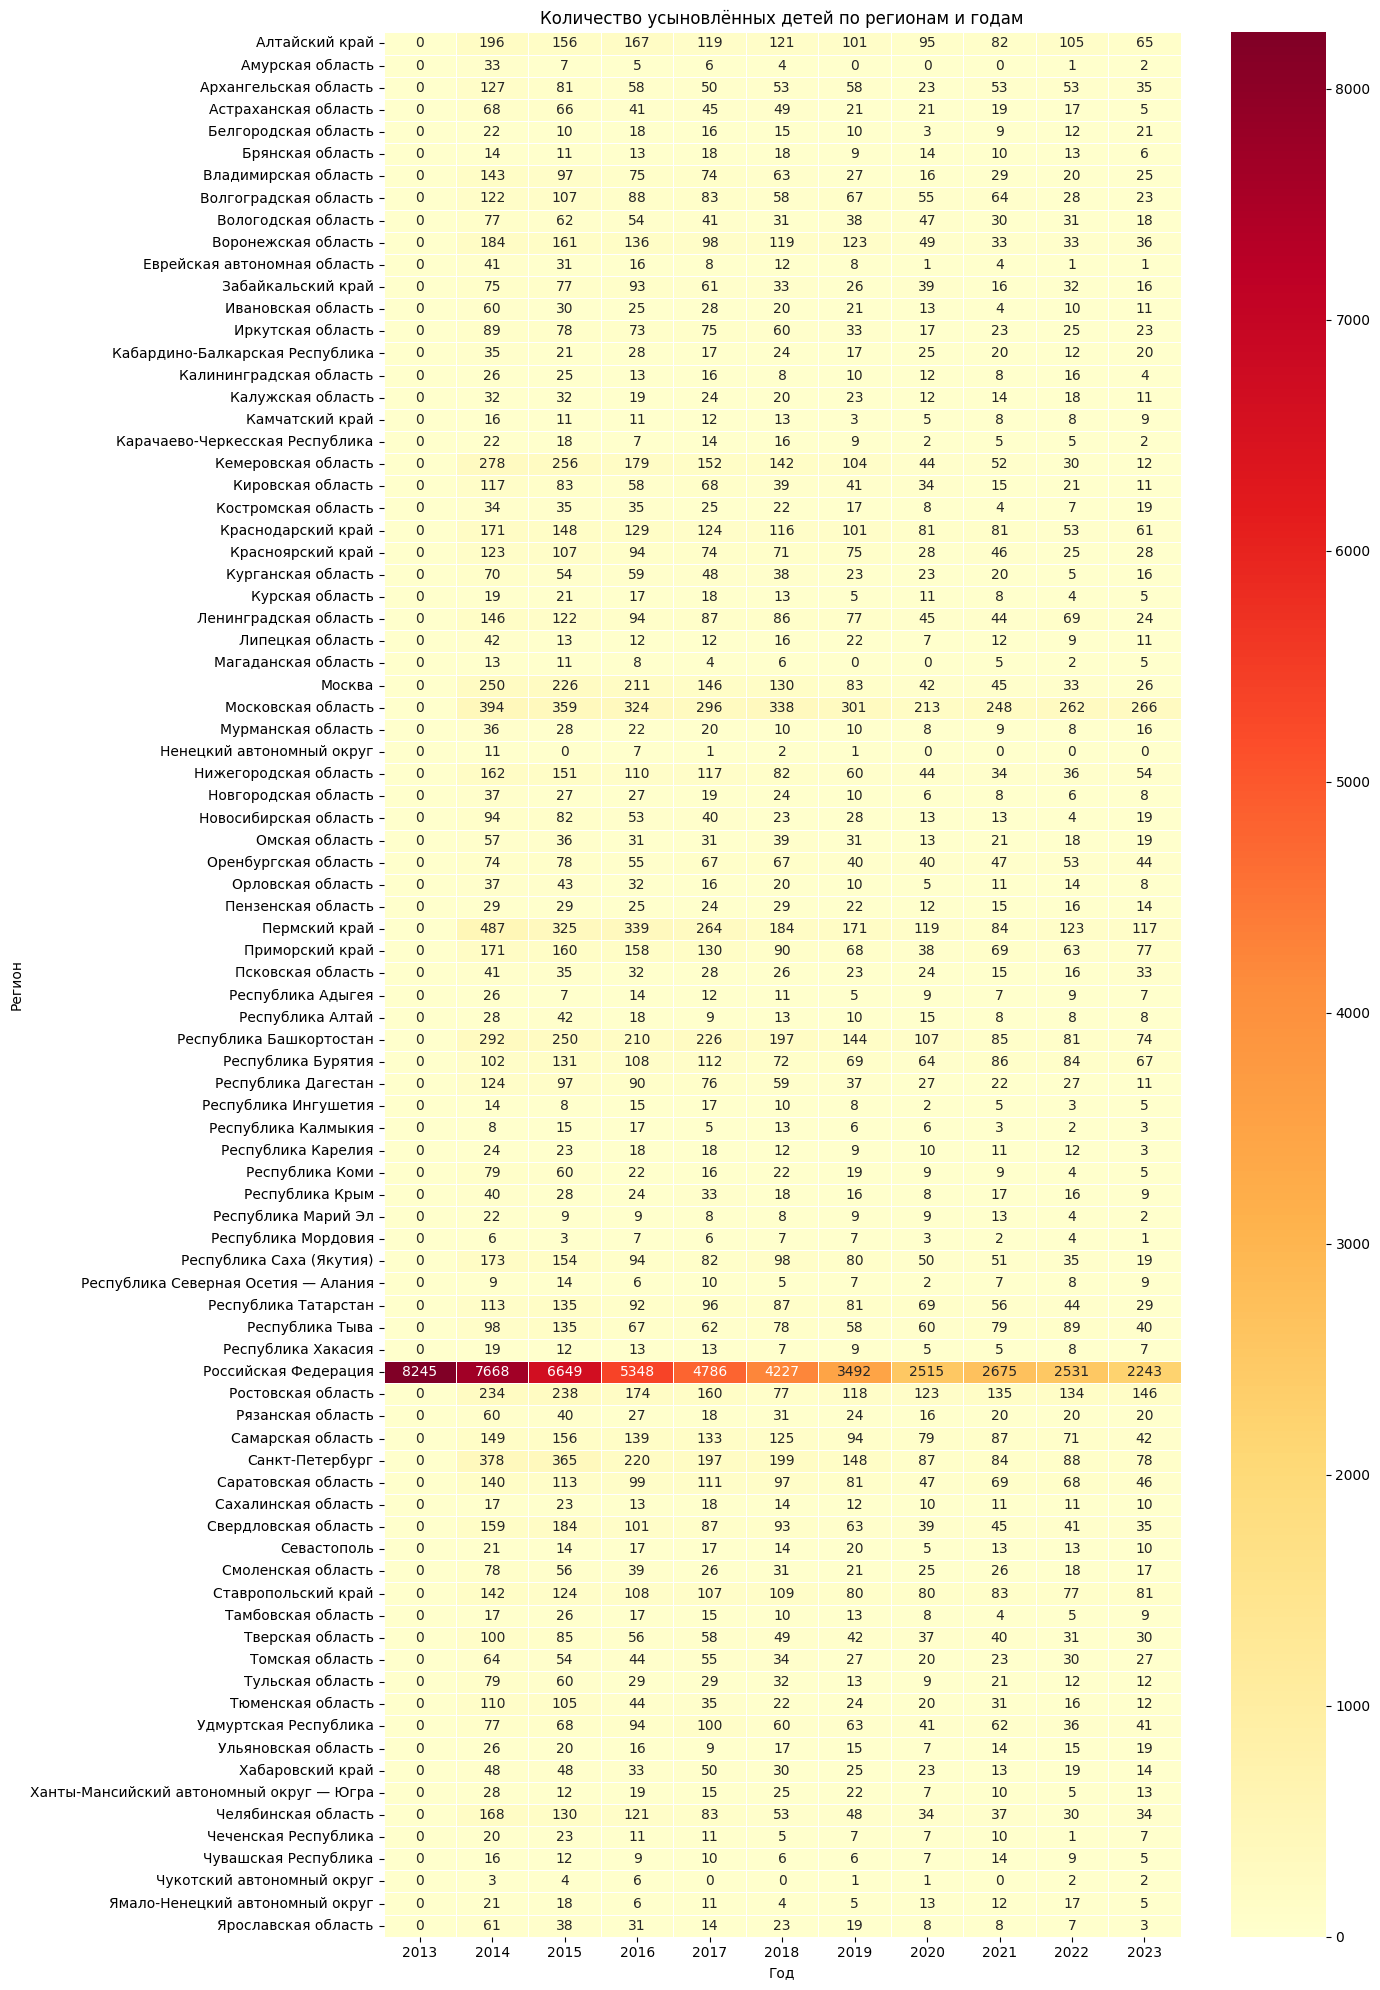

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 20))
sns.heatmap(pivot_adopt, cmap='YlOrRd', annot=True, fmt='.0f', linewidths=.5)
plt.title('Количество усыновлённых детей по регионам и годам')
plt.xlabel('Год')
plt.ylabel('Регион')
plt.tight_layout()
plt.show()